In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
results = pd.read_csv(r"C:\Users\ajeet\Downloads\archive\results.csv")

results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
data = results.copy()

data["date"] = pd.to_datetime(data["date"])
data["year"] = data["date"].dt.year

data = data.dropna(subset=["home_score", "away_score"])

data["goal_difference"] = data["home_score"] - data["away_score"]

data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,goal_difference
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,3.0


In [4]:
df = data[[
    "year",
    "home_team",
    "away_team",
    "tournament",
    "country",
    "neutral",
    "goal_difference"
]].copy()

df.head()

,year,home_team,away_team,tournament,country,neutral,goal_difference
0,1872,Scotland,England,Friendly,Scotland,False,0.0
1,1873,England,Scotland,Friendly,England,False,2.0
2,1874,Scotland,England,Friendly,Scotland,False,1.0
3,1875,England,Scotland,Friendly,England,False,0.0
4,1876,Scotland,England,Friendly,Scotland,False,3.0


In [5]:
label_encoders = {}

categorical_columns = ["home_team", "away_team", "tournament", "country", "neutral"]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

df.head()

,year,home_team,away_team,tournament,country,neutral,goal_difference
0,1872,250,88,94,205,0,0.0
1,1873,86,245,94,71,0,2.0
2,1874,250,88,94,205,0,1.0
3,1875,86,245,94,71,0,0.0
4,1876,250,88,94,205,0,3.0


In [6]:
X = df[["year", "home_team", "away_team", "tournament", "country", "neutral"]]
y = df["goal_difference"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 1.7375277820237118
Mean Squared Error: 6.036959466772805


In [8]:
def safe_encode(column, value):
    le = label_encoders[column]

    if value in le.classes_:
        return le.transform([value])[0]
    else:
        return 0

In [9]:
def predict_match_linear(home_team, away_team, tournament="FIFA World Cup", country="United States", neutral=True, year=2026):
    match = pd.DataFrame([{
        "year": year,
        "home_team": safe_encode("home_team", home_team),
        "away_team": safe_encode("away_team", away_team),
        "tournament": safe_encode("tournament", tournament),
        "country": safe_encode("country", country),
        "neutral": safe_encode("neutral", neutral)
    }])

    predicted_goal_diff = linear_model.predict(match)[0]

    print(f"Match: {home_team} vs {away_team}")
    print(f"Predicted Goal Difference: {predicted_goal_diff:.2f}")

    if predicted_goal_diff > 0.3:
        print(f"Predicted Winner: {home_team}")
    elif predicted_goal_diff < -0.3:
        print(f"Predicted Winner: {away_team}")
    else:
        print("Predicted Result: Draw")

In [10]:
predict_match_linear("Argentina", "France")

Match: Argentina vs France
Predicted Goal Difference: 0.48
Predicted Winner: Argentina


In [11]:
predict_match_linear("Brazil", "England")

Match: Brazil vs England
Predicted Goal Difference: 0.50
Predicted Winner: Brazil


In [12]:
predict_match_linear("Spain", "Morocco")

Match: Spain vs Morocco
Predicted Goal Difference: 0.62
Predicted Winner: Spain


In [16]:
def convert_goal_diff_to_chances(goal_diff):
    """
    Converts predicted goal difference into estimated chances.
    This is not a true probability model, but a simple visualization method.
    """

    home_strength = np.exp(goal_diff * 0.7)
    away_strength = np.exp(-goal_diff * 0.7)
    draw_strength = 0.9 * np.exp(-abs(goal_diff) * 0.7)

    total = home_strength + away_strength + draw_strength

    home_win_chance = home_strength / total
    draw_chance = draw_strength / total
    away_win_chance = away_strength / total

    return home_win_chance, draw_chance, away_win_chance

In [17]:
sample_matches = [
    ("Argentina", "France"),
    ("Brazil", "England"),
    ("Spain", "Morocco"),
    ("Germany", "Portugal"),
    ("Netherlands", "Croatia")
]

chance_results = []

for home_team, away_team in sample_matches:
    match = pd.DataFrame([{
        "year": 2026,
        "home_team": safe_encode("home_team", home_team),
        "away_team": safe_encode("away_team", away_team),
        "tournament": safe_encode("tournament", "FIFA World Cup"),
        "country": safe_encode("country", "United States"),
        "neutral": safe_encode("neutral", True)
    }])

    predicted_goal_diff = linear_model.predict(match)[0]

    home_chance, draw_chance, away_chance = convert_goal_diff_to_chances(predicted_goal_diff)

    chance_results.append({
        "Match": home_team + " vs " + away_team,
        "Home Win Chance": home_chance * 100,
        "Draw Chance": draw_chance * 100,
        "Away Win Chance": away_chance * 100
    })

chance_df = pd.DataFrame(chance_results)

chance_df

,Match,Home Win Chance,Draw Chance,Away Win Chance
0,Argentina vs France,50.613657,23.393531,25.992812
1,Brazil vs England,51.397080,23.022436,25.580484
2,Spain vs Morocco,55.517796,21.070518,23.411686
3,Germany vs Portugal,51.028859,23.196856,25.774285
4,Netherlands vs Croatia,55.447421,21.103853,23.448726


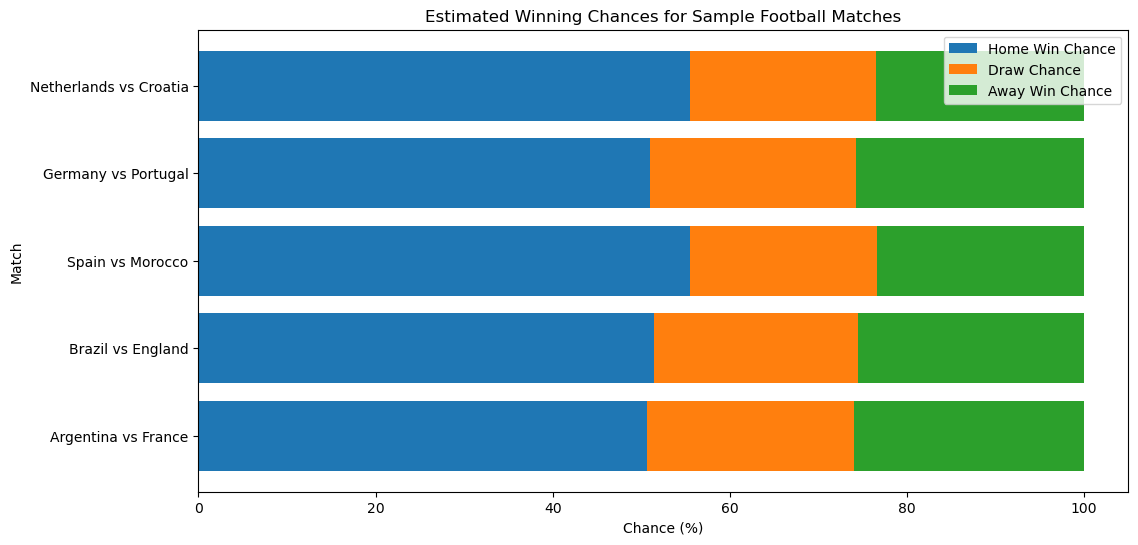

In [18]:
plt.figure(figsize=(12, 6))

plt.barh(chance_df["Match"], chance_df["Home Win Chance"], label="Home Win Chance")
plt.barh(
    chance_df["Match"],
    chance_df["Draw Chance"],
    left=chance_df["Home Win Chance"],
    label="Draw Chance"
)
plt.barh(
    chance_df["Match"],
    chance_df["Away Win Chance"],
    left=chance_df["Home Win Chance"] + chance_df["Draw Chance"],
    label="Away Win Chance"
)

plt.title("Estimated Winning Chances for Sample Football Matches")
plt.xlabel("Chance (%)")
plt.ylabel("Match")
plt.legend()

plt.show()